# 2022-C题学习指南（1）：数据预处理

**主题：古代玻璃制品的成分分析与鉴别**

本 notebook 面向第一次接触数学建模数据处理的学生。我们暂不建立分类模型，先把原始附件整理成**可解释、可验证、可继续建模**的数据。

学习方式：阅读讲解，运行教师示例，补全带有 `TODO` 的函数，再运行其下方从 `tests/` 目录导入的自动测试。

> 初始模板中的练习函数尚未实现，所以测试会显示“尚未完成”，但不会中断整本 notebook。完成代码后重新运行练习与测试单元即可。

## Goal

完成本章后，你应该能够：

1. 正确读取多工作表 Excel，并保护 `01` 这类编号的前导零；
2. 区分“未检测到”“普通缺失”和数值 0；
3. 按题目给出的 85%～105% 规则筛选有效成分数据；
4. 把文物采样点拆分为文物编号和采样点，并识别采样面状态；
5. 将文物基本信息与化学成分表安全连接；
6. 识别多采样点带来的重复测量问题；
7. 使用自动测试检查预处理函数的正确性。

## Setup

### 运行环境

推荐 Python 3.10 或更高版本，并安装：

```bash
pip install pandas numpy matplotlib openpyxl nbformat termcolor
```

请将本 notebook 保留在 `数学建模课程设计案例` 文件夹中，原始数据位于 `data/2022c-附件.xlsx`。

### 跨平台绘图字体

初始化代码会检测当前系统中实际安装的中文字体：macOS 优先使用苹方/冬青黑体，Windows 优先使用微软雅黑/黑体，Linux 优先使用 Noto/思源黑体。当前示例图的标题与坐标轴使用英文，化学成分刻度使用化学式，因此即使系统没有中文字体也不会出现缺失中文字形警告。

In [1]:
from pathlib import Path
import importlib
import os
import platform
import re
import sys
import tempfile

# 避免 Matplotlib 在受限环境下写入用户目录。
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "matplotlib-2022c-course"))

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")


def configure_cross_platform_fonts():
    """选择系统中真实存在的中文字体；图表仍使用ASCII标签作为最终回退。"""
    system = platform.system()
    platform_candidates = {
        "Darwin": ["PingFang SC", "Hiragino Sans GB", "Heiti SC", "Songti SC"],
        "Windows": ["Microsoft YaHei", "SimHei", "DengXian", "SimSun"],
        "Linux": ["Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Zen Hei"],
    }
    common_fallbacks = [
        "Microsoft YaHei", "PingFang SC", "Hiragino Sans GB",
        "Noto Sans CJK SC", "Source Han Sans SC", "SimHei", "Songti SC",
    ]
    candidates = platform_candidates.get(system, []) + common_fallbacks
    installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
    selected_font = next((name for name in candidates if name in installed_fonts), None)

    plt.rcParams["font.family"] = "sans-serif"
    if selected_font is not None:
        plt.rcParams["font.sans-serif"] = [selected_font, "DejaVu Sans"]
    else:
        # 本 notebook 的图形文字使用英文和化学式，因此没有中文字体时仍可安全绘图。
        plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return selected_font


CJK_FONT = configure_cross_platform_fonts()
print("Matplotlib中文字体：", CJK_FONT or "未检测到；当前图形将使用英文/化学式标签")


def locate_data_file():
    # 在常见运行目录中寻找课程附件。
    relative = Path("data") / "2022c-附件.xlsx"
    candidates = [
        Path.cwd() / relative,
        Path.cwd() / "数学建模课程设计案例" / relative,
        Path.cwd().parent / relative,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(f"找不到 2022c-附件.xlsx，已检查：\n{searched}")


DATA_FILE = locate_data_file()
CASE_DIR = DATA_FILE.parent.parent
TESTS_DIR = CASE_DIR / "tests"
NOTEBOOK_FILE = CASE_DIR / "2022-C题学习指南-01-数据预处理.ipynb"
print(f"数据文件：{DATA_FILE}")

Matplotlib is building the font cache; this may take a moment.


Matplotlib中文字体： Hiragino Sans GB
数据文件：/Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例/data/2022c-附件.xlsx


### 外部自动测试

与实验1一致，测试实现与学生作答分离：

- `tests/base_test_suite.py`：负责从 notebook 收集评分函数、记录结果和计算成绩；
- `tests/test_suite_2022c_preprocessing.py`：包含本章五道编程练习的测试用例。

不要在 notebook 中修改测试。完成练习后直接运行对应的测试调用单元；需要统一评分时，先保存 notebook，再运行最后的评分单元。

In [2]:
if str(TESTS_DIR) not in sys.path:
    sys.path.insert(0, str(TESTS_DIR))

import base_test_suite
import test_suite_2022c_preprocessing

# 便于教师在修改测试文件后直接重新运行本单元。
importlib.reload(base_test_suite)
importlib.reload(test_suite_2022c_preprocessing)

from test_suite_2022c_preprocessing import TestSuite2022CPreprocessing

testsuite = TestSuite2022CPreprocessing()
print(f"测试目录：{TESTS_DIR}")

测试目录：/Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例/tests


## Steps

## 1. 认识数据表与数据粒度

附件有三个工作表：

- **表单1**：每行是一件文物，共58件；
- **表单2**：每行是一个已分类采样点。同一件文物可能有多个采样点；
- **表单3**：每行是一件待鉴别文物。

“一行代表什么”称为数据的**粒度**。表单1按文物，表单2按采样点，二者不能仅凭行号横向拼接。

In [3]:
# 教师示例：一次读取全部工作表，并将可能出现的编号列读取为字符串。
raw_tables = pd.read_excel(
    DATA_FILE,
    sheet_name=None,
    dtype={"文物编号": "string", "文物采样点": "string"},
)

table1_raw = raw_tables["表单1"]
table2_raw = raw_tables["表单2"]
table3_raw = raw_tables["表单3"]

overview = pd.DataFrame(
    {
        "工作表": list(raw_tables),
        "行数": [len(df) for df in raw_tables.values()],
        "列数": [df.shape[1] for df in raw_tables.values()],
        "数据粒度": ["文物", "采样点", "待鉴别文物"],
    }
)
overview

,工作表,行数,列数,数据粒度
0,表单1,58,5,文物
1,表单2,69,15,采样点
2,表单3,8,16,待鉴别文物


In [4]:
display(Markdown("**表单1预览**"))
display(table1_raw.head(3))
display(Markdown("**表单2预览**"))
display(table2_raw.head(3))
display(Markdown("**表单3预览**"))
display(table3_raw.head(3))

**表单1预览**

,文物编号,纹饰,类型,颜色,表面风化
0,01,C,高钾,蓝绿,无风化
1,02,A,铅钡,浅蓝,风化
2,03,A,高钾,蓝绿,无风化


**表单2预览**

,文物采样点,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2)
0,01,69.33,NaN,9.99,6.32,0.87,3.93,1.74,3.87,NaN,NaN,1.17,NaN,NaN,0.39
1,02,36.28,NaN,1.05,2.34,1.18,5.73,1.86,0.26,47.43,NaN,3.57,0.19,NaN,NaN
2,03部位1,87.05,NaN,5.19,2.01,NaN,4.06,NaN,0.78,0.25,NaN,0.66,NaN,NaN,NaN


**表单3预览**

,文物编号,表面风化,二氧化硅(SiO2),氧化钠(Na2O),氧化钾(K2O),氧化钙(CaO),氧化镁(MgO),氧化铝(Al2O3),氧化铁(Fe2O3),氧化铜(CuO),氧化铅(PbO),氧化钡(BaO),五氧化二磷(P2O5),氧化锶(SrO),氧化锡(SnO2),二氧化硫(SO2)
0,A1,无风化,78.45,NaN,NaN,6.08,1.86,7.23,2.15,2.11,NaN,NaN,1.06,0.03,NaN,0.51
1,A2,风化,37.75,NaN,NaN,7.63,NaN,2.33,NaN,NaN,34.30,NaN,14.27,NaN,NaN,NaN
2,A3,无风化,31.95,NaN,1.36,7.19,0.81,2.93,7.06,0.21,39.58,4.69,2.68,0.52,NaN,NaN


### 练习1：编写数据读取函数

补全 `load_case_workbook`：

- 返回键为 `表单1`、`表单2`、`表单3` 的字典；
- 值必须是 `DataFrame`；
- `文物编号`、`文物采样点` 应保留为字符串，尤其不能把 `01` 变成 `1`。

In [5]:
# UNQ_C1（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: load_case_workbook
def load_case_workbook(file_path):
    """读取2022-C题附件，并返回三个工作表。"""
    # 你的代码从这里开始
    # 第1步：使用pd.read_excel一次读取全部工作表。
    # sheet_name=None表示返回“工作表名称 -> DataFrame”的字典。
    # dtype参数要保护“文物编号”和“文物采样点”的前导零。
    workbook = ...

    # 第2步：分别从workbook中取出表单1、表单2和表单3。
    table_1 = ...
    table_2 = ...
    table_3 = ...

    # 第3步：按规定的键名组织返回结果。
    result = {
        "表单1": table_1,
        "表单2": table_2,
        "表单3": table_3,
    }
    # 你的代码到这里结束

    return result

In [6]:
testsuite.test_load_case_workbook(load_case_workbook)

测试失败 test_load_case_workbook：字典中的每个值都应为 DataFrame


## 2. 数据类型与标识符

文物编号看起来像数字，但它不参与加减乘除，因此属于**分类标识符**。如果按整数读取，`01` 会变成 `1`，后续连接数据时容易匹配失败。

表单2的 `文物采样点` 同时保存了两项信息：

- 开头两位数字是**文物编号**；
- 两位数字之后的文字是**采样点**，例如 `部位2`、`未风化点`、`严重风化点`。

我们要把这一列拆成一个新的两列 `DataFrame`：`文物编号`、`采样点`。对于 `01`、`02` 这种只有编号、没有位置文字的记录，本课程约定将采样点设为默认值 `部位1`。

下面使用 Pandas 的向量化字符串方法：

1. `astype("string")`：使用可保留缺失值的字符串类型；
2. `str.extract(r"^(\d{2})", expand=False)`：提取开头两位数字；
3. `str.replace(r"^\d{2}", "", regex=True)`：删除开头编号，留下采样点文字；
4. `replace("", "部位1")`：只把空字符串替换为默认采样点；
5. `pd.DataFrame({...})`：把两个结果组合为结构清晰的两列表。

这些操作直接作用于附件中的完整列，不需要手工构造示例字符串，也不需要逐行编写循环。

In [7]:
# 教师示例：直接拆分从附件表单2读取到的完整“文物采样点”列。
sampling_labels = table2_raw["文物采样点"].astype("string")

sampling_point_demo = pd.DataFrame(
    {
        "文物编号": sampling_labels.str.extract(r"^(\d{2})", expand=False),
        "采样点": (
            sampling_labels
            .str.replace(r"^\d{2}", "", regex=True)
            .replace("", "部位1")
        ),
    },
    index=table2_raw.index,
)

display(Markdown("**拆分后的前10行**"))
display(sampling_point_demo.head(10))

display(Markdown("**几种不同命名形式的拆分结果**"))
display(
    pd.concat(
        [table2_raw[["文物采样点"]], sampling_point_demo],
        axis=1,
    ).loc[
        table2_raw["文物采样点"].isin(
            ["01", "03部位2", "08严重风化点", "23未风化点"]
        )
    ]
)

**拆分后的前10行**

,文物编号,采样点
0,01,部位1
1,02,部位1
2,03,部位1
3,03,部位2
4,04,部位1
5,05,部位1
6,06,部位1
7,06,部位2
8,07,部位1
9,08,部位1


**几种不同命名形式的拆分结果**

,文物采样点,文物编号,采样点
0,01,01,部位1
3,03部位2,03,部位2
10,08严重风化点,08,严重风化点
25,23未风化点,23,未风化点


### 练习2：将文物采样点拆分为两列

补全 `split_sampling_points`，返回且仅返回 `文物编号`、`采样点` 两列。

请使用讲解中相同的向量化方法：`astype("string")`、`str.extract`、`str.replace`、`replace` 和 `pd.DataFrame`，不要使用手工构造的数据或逐行循环。

与讲解代码相比，本练习把**列名**和**默认采样点**变成函数参数。外部测试会从真实表单2中选择另一组记录，把原列改名为 `采样标签`，并使用不同的默认值 `常规部位`，以检查函数是否真正可复用；随后还会用完整附件和默认值 `部位1` 复核结果。

In [8]:
# UNQ_C2（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: split_sampling_points
def split_sampling_points(data, label_column, default_sampling_point):
    """将指定采样标签列拆分成文物编号和采样点两列。"""
    # 你的代码从这里开始
    # 第1步：取出label_column列，并转换为pandas的string类型。
    labels = ...

    # 第2步：使用str.extract和正则表达式提取开头的两位文物编号。
    artifact_ids = ...

    # 第3步：使用str.replace删除开头的两位编号，得到采样点文字。
    sampling_points = ...

    # 第4步：只含编号的记录会得到空字符串；将其替换为default_sampling_point。
    sampling_points = ...

    # 第5步：构造且仅包含“文物编号”“采样点”两列的DataFrame。
    result = ...
    # 你的代码到这里结束

    return result

In [9]:
testsuite.test_split_sampling_points(split_sampling_points)

测试失败 test_split_sampling_points：应返回 DataFrame


## 3. “未检测到”不等于普通缺失

题目明确说明：化学成分表中的空白表示**未检测到该成分**。这与“忘记记录”或“文件损坏”不同。

在本题的成分求和中，可以把未检出成分按0处理；但在后续进行对数计算时，`log(0)` 不存在，需要另行处理并报告规则。

不要对所有列直接 `fillna(0)`：表单1中缺失的颜色不是浓度0。

In [10]:
component_columns = list(table2_raw.columns[1:])
non_detection_summary = (
    table2_raw[component_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("未检出比例(%)")
    .to_frame()
)
non_detection_summary.round(1)

,未检出比例(%)
氧化锡(SnO2),89.9
二氧化硫(SO2),88.4
氧化钠(Na2O),72.5
氧化钾(K2O),40.6
氧化镁(MgO),36.2
氧化铁(Fe2O3),34.8
氧化锶(SrO),33.3
氧化钡(BaO),23.2
氧化铅(PbO),15.9
五氧化二磷(P2O5),14.5


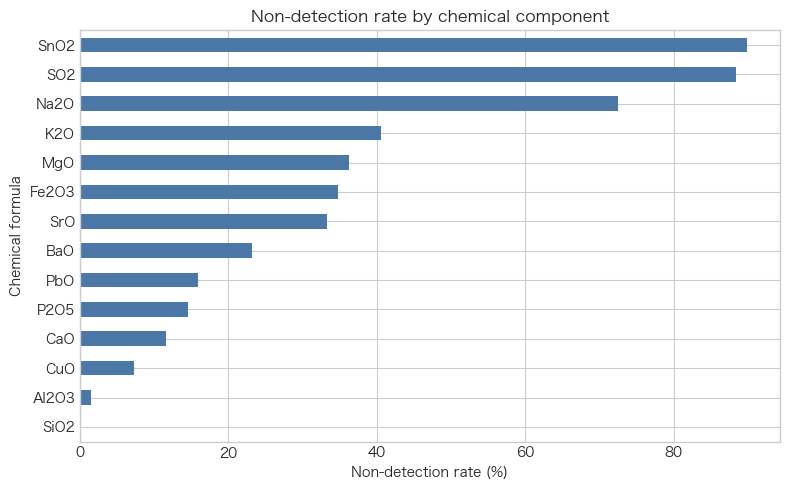

In [11]:
# 图形刻度使用化学式（ASCII），避免不同操作系统的中文字库差异。
non_detection_plot_data = non_detection_summary.copy()
formula_labels = non_detection_plot_data.index.to_series().str.extract(
    r"\(([^()]*)\)", expand=False
)
if formula_labels.isna().any():
    # 极端情况下使用稳定的英文序号，不把中文名称交给缺少中文字形的字体。
    formula_labels = pd.Series(
        [f"Component {index + 1}" for index in range(len(non_detection_plot_data))],
        index=non_detection_plot_data.index,
    )
non_detection_plot_data.index = formula_labels.to_numpy()

ax = non_detection_plot_data.sort_values("未检出比例(%)").plot.barh(
    figsize=(8, 5), legend=False, color="#4C78A8"
)
ax.set_title("Non-detection rate by chemical component")
ax.set_xlabel("Non-detection rate (%)")
ax.set_ylabel("Chemical formula")
plt.tight_layout()
plt.show()

### 练习3：只处理化学成分列的未检出值

补全 `fill_not_detected_zero`：

- 返回新的 `DataFrame`，不要修改输入对象；
- 只在给定的成分列中将空白替换为0；
- 其他列中的缺失值必须保留。

In [12]:
# UNQ_C3（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: fill_not_detected_zero
def fill_not_detected_zero(data, components):
    """仅把指定化学成分列的未检出值替换为0。"""
    # 你的代码从这里开始
    # 第1步：使用copy(deep=True)复制输入，避免修改原始DataFrame。
    result = ...

    # 第2步：只选择components指定的化学成分列。
    component_data = ...

    # 第3步：对这些成分列使用fillna(0)，表示题目中的“未检测到”。
    result[components] = ...

    # 注意：不要对颜色等非成分列执行fillna(0)。
    # 你的代码到这里结束

    return result

In [13]:
testsuite.test_fill_not_detected_zero(fill_not_detected_zero)

测试失败 test_fill_not_detected_zero：'ellipsis' object does not support item assignment


## 4. 成分总和与有效性筛选

14种化学成分是百分比数据，理论总和应接近100%。题目允许检测误差，并规定：

$$85\% \leq \sum_{j=1}^{14} x_j \leq 105\%$$

边界85和105都属于有效值。质量标记应保留在数据中，而不是立即删除原始行，这样才能追踪被排除的样本。

In [14]:
# 教师示例：显式按0处理未检出值，再计算总和与有效标记。
quality_demo = table2_raw[["文物采样点"] + component_columns].copy()
quality_demo["成分总和"] = quality_demo[component_columns].fillna(0).sum(axis=1)
quality_demo["是否有效"] = quality_demo["成分总和"].between(85, 105, inclusive="both")

display(quality_demo["是否有效"].value_counts().rename_axis("是否有效").to_frame("采样点数"))
display(quality_demo.loc[~quality_demo["是否有效"], ["文物采样点", "成分总和"]])

,采样点数
是否有效,
True,67
False,2


,文物采样点,成分总和
17,15,79.47
19,17,71.89


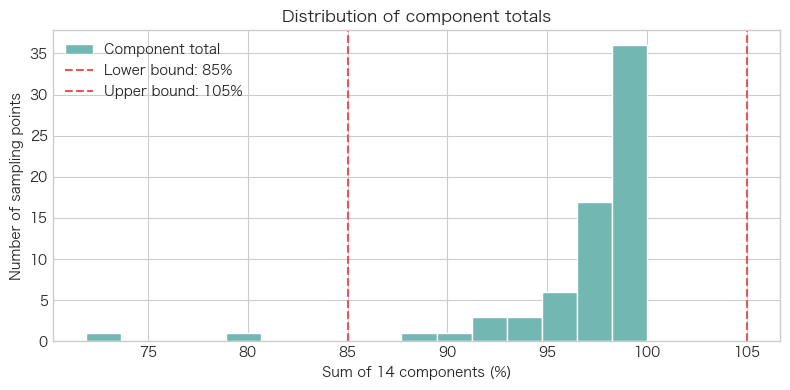

In [15]:
# 重命名Series，防止pandas把中文变量名作为隐藏图形文本传给Matplotlib。
component_totals_for_plot = quality_demo["成分总和"].rename("Component total")
ax = component_totals_for_plot.plot.hist(
    bins=16, figsize=(8, 4), color="#72B7B2", edgecolor="white"
)
ax.axvline(85, color="#E45756", linestyle="--", label="Lower bound: 85%")
ax.axvline(105, color="#E45756", linestyle="--", label="Upper bound: 105%")
ax.set_title("Distribution of component totals")
ax.set_xlabel("Sum of 14 components (%)")
ax.set_ylabel("Number of sampling points")
ax.legend()
plt.tight_layout()
plt.show()

### 练习4：添加质量控制列

补全 `add_composition_quality`：返回副本并添加 `成分总和`、`是否有效` 两列。函数应允许调用者传入上下界，并正确处理闭区间边界。

In [16]:
# UNQ_C4（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: add_composition_quality
def add_composition_quality(data, components, lower=85, upper=105):
    """添加成分总和及有效性标记，不修改输入数据。"""
    # 你的代码从这里开始
    # 第1步：深复制输入DataFrame，保护原始数据。
    result = ...

    # 第2步：选择components列，把未检出值临时按0处理后逐行求和。
    component_totals = ...

    # 第3步：把逐行总和保存为“成分总和”列。
    result["成分总和"] = ...

    # 第4步：使用between判断总和是否在[lower, upper]闭区间内。
    result["是否有效"] = ...
    # 你的代码到这里结束

    return result

In [17]:
testsuite.test_add_composition_quality(add_composition_quality)

测试失败 test_add_composition_quality：'ellipsis' object does not support item assignment


## 5. 解析采样面状态并连接表格

连接规则来自题目说明：

1. 普通采样点和“部位1/部位2”继承表单1中该文物的风化状态；
2. 名称含“未风化点”时，采样面状态设为“无风化”；
3. 名称含“严重风化点”时，采样面状态设为“严重风化”。

连接时建议使用 `validate="many_to_one"`：表单2的多个采样点可以对应表单1的一件文物，但表单1中的文物编号必须唯一。

In [18]:
# 教师示例：复用第2节的拆分结果构造分析用连接表。
analysis_demo = quality_demo.copy()
analysis_demo[["文物编号", "采样点"]] = sampling_point_demo
analysis_demo = analysis_demo.merge(
    table1_raw,
    on="文物编号",
    how="left",
    validate="many_to_one",
)
analysis_demo["采样面状态"] = analysis_demo["表面风化"]
analysis_demo.loc[
    analysis_demo["采样点"].str.contains("未风化点", na=False), "采样面状态"
] = "无风化"
analysis_demo.loc[
    analysis_demo["采样点"].str.contains("严重风化点", na=False), "采样面状态"
] = "严重风化"

analysis_demo.loc[
    analysis_demo["文物采样点"].isin(["03部位1", "23未风化点", "08严重风化点"]),
    ["文物采样点", "文物编号", "采样点", "类型", "表面风化", "采样面状态"],
]

,文物采样点,文物编号,采样点,类型,表面风化,采样面状态
2,03部位1,03,部位1,高钾,无风化,无风化
10,08严重风化点,08,严重风化点,铅钡,风化,严重风化
25,23未风化点,23,未风化点,铅钡,风化,无风化


### 练习5：构建可建模的分析表

补全 `build_analysis_table`。输出至少应包含：原始采样点、拆分后的采样点、14种成分、两列质量标记、文物编号、类型、纹饰、颜色、文物表面风化状态及采样面状态。

建议复用 `split_sampling_points` 和前面的质量控制函数，而不是重新复制同一段逻辑。

In [19]:
# UNQ_C5（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: build_analysis_table
def build_analysis_table(basic_info, chemical_data):
    """连接文物信息与采样点成分，并添加质量及采样面状态。"""
    # 你的代码从这里开始
    # 第1步：取得chemical_data中的14个化学成分列名。
    components = ...

    # 第2步：调用add_composition_quality添加成分总和和有效性标记。
    analysis_table = ...

    # 第3步：调用split_sampling_points拆分文物采样点；默认部位为“部位1”。
    sampling_info = ...

    # 第4步：把拆分得到的“文物编号”“采样点”两列加入分析表。
    analysis_table[["文物编号", "采样点"]] = ...

    # 第5步：按文物编号连接basic_info；使用many_to_one检查基本信息键唯一。
    analysis_table = ...

    # 第6步：先让普通采样点继承文物的“表面风化”状态。
    analysis_table["采样面状态"] = ...

    # 第7步：找出采样点名称中包含“未风化点”的记录，并改为“无风化”。
    no_weathering_mask = ...
    analysis_table.loc[no_weathering_mask, "采样面状态"] = ...

    # 第8步：找出包含“严重风化点”的记录，并改为“严重风化”。
    severe_weathering_mask = ...
    analysis_table.loc[severe_weathering_mask, "采样面状态"] = ...
    # 你的代码到这里结束

    return analysis_table

In [20]:
testsuite.test_build_analysis_table(build_analysis_table)

测试失败 test_build_analysis_table：'ellipsis' object does not support item assignment


## 6. 重复测量与建模泄漏

表单2有69个采样点，但只来自58件文物。某些文物有多个部位或不同风化区域的检测结果，这些行彼此相关。

如果随机按“行”划分训练集和测试集，同一件文物的两个采样点可能分别进入两侧，模型等于提前看过测试对象，准确率会偏高。后续建模应按 `文物编号` 分组划分或进行分组交叉验证。

In [21]:
sampling_counts = (
    analysis_demo.groupby("文物编号", dropna=False)
    .size()
    .rename("采样点数")
    .sort_values(ascending=False)
)

sampling_summary = pd.Series(
    {
        "采样点总数": len(analysis_demo),
        "文物数": analysis_demo["文物编号"].nunique(),
        "具有多个采样点的文物数": int((sampling_counts > 1).sum()),
        "单件文物最大采样点数": int(sampling_counts.max()),
    },
    name="数量",
)
display(sampling_summary.to_frame())
display(sampling_counts[sampling_counts > 1].to_frame())

,数量
采样点总数,69
文物数,58
具有多个采样点的文物数,11
单件文物最大采样点数,2


,采样点数
文物编号,
30,2
54,2
49,2
50,2
51,2
26,2
43,2
42,2
08,2


## 7. 导出供后续章节复用的预处理数据

数据清洗规则只应实现一次。下面把本章教师示例形成的标准结果保存到 `data/processed/`，供“统计分析与假设检验”等后续 notebook 直接读取：

- `2022c-文物信息.csv`：一行一件文物，适合分类变量列联分析；
- `2022c-有效采样点.csv`：一行一个通过 85%～105% 质量检查的采样点，保留文物编号和采样部位；
- `2022c-文物采样面.csv`：一行表示一件文物的一种采样面状态；同一文物同一状态有多个记录时，对 14 种成分取均值。

这种“保存中间数据产品”的做法使后续章节能独立重启和运行，同时避免复制拆分编号、处理未检出值、判定有效性和解析采样面状态的代码。若修改了本章清洗规则，请重新运行本单元以更新三个文件。

In [22]:
# 导出稳定的数据接口，后续章节只负责分析，不重复清洗。
PROCESSED_DIR = DATA_FILE.parent / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_basic = table1_raw.copy()
processed_valid_samples = analysis_demo.loc[analysis_demo["是否有效"]].copy()
processed_valid_samples[component_columns] = processed_valid_samples[component_columns].fillna(0)

processed_artifact_surface = (
    processed_valid_samples
    .groupby(["文物编号", "类型", "采样面状态"], as_index=False)[component_columns]
    .mean()
)

processed_files = {
    "文物信息": PROCESSED_DIR / "2022c-文物信息.csv",
    "有效采样点": PROCESSED_DIR / "2022c-有效采样点.csv",
    "文物采样面": PROCESSED_DIR / "2022c-文物采样面.csv",
}
processed_basic.to_csv(processed_files["文物信息"], index=False, encoding="utf-8-sig")
processed_valid_samples.to_csv(processed_files["有效采样点"], index=False, encoding="utf-8-sig")
processed_artifact_surface.to_csv(processed_files["文物采样面"], index=False, encoding="utf-8-sig")

export_summary = pd.DataFrame({
    "数据文件": [path.name for path in processed_files.values()],
    "行数": [len(processed_basic), len(processed_valid_samples), len(processed_artifact_surface)],
    "分析单位": ["文物", "有效采样点", "文物 × 采样面状态"],
})
display(export_summary)
print(f"预处理数据已保存到：{PROCESSED_DIR}")

,数据文件,行数,分析单位
0,2022c-文物信息.csv,58,文物
1,2022c-有效采样点.csv,67,有效采样点
2,2022c-文物采样面.csv,61,文物 × 采样面状态


预处理数据已保存到：/Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例/data/processed


### 思考题（文字作答）

1. 为什么不能用 `table1.join(table2)` 按行号直接连接两张表？
2. 如果要预测“文物类型”，训练测试划分应按文物还是按采样点？为什么？
3. 表单1中颜色为空和表单2中某种氧化物为空，处理方法为什么不同？
4. 无效采样点应当删除、保留还是单独分析？请说明你的选择及其对模型的影响。

这些问题没有唯一代码答案，建议在下方新建 Markdown 单元作答，并与同学互相审阅。

## Checks

### 最终评分

逐题测试使用当前内核中的函数，所以适合边写边检查。下方统一评分会像实验1一样，从**已保存的 notebook 文件**重新收集所有带 `# GRADED FUNCTION:` 标记的函数。

运行前请先保存 notebook。五道练习全部完成时应显示 `5 / 5`，自动评分为100分。

In [23]:
stu_grade = testsuite.grade_all_tests(NOTEBOOK_FILE)
print(f"本章自动评分：{stu_grade}")

正在从 notebook 收集评分函数：/Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例/2022-C题学习指南-01-数据预处理.ipynb
测试失败 test_load_case_workbook：字典中的每个值都应为 DataFrame
测试失败 test_split_sampling_points：应返回 DataFrame
测试失败 test_fill_not_detected_zero：'ellipsis' object does not support item assignment
测试失败 test_add_composition_quality：'ellipsis' object does not support item assignment
测试失败 test_build_analysis_table：'ellipsis' object does not support item assignment

通过 0 / 5 道练习测试
自动评分成绩：0
本章自动评分：0


### 建模前的数据检查清单

在进入统计分析或分类模型之前，确认：

- [ ] 数据文件和三个工作表均成功读取；
- [ ] 编号的前导零得到保留；
- [ ] 只把化学成分中的未检出值按规则处理；
- [ ] 成分总和采用14种化学成分计算；
- [ ] 有效区间包含85和105两个边界；
- [ ] 15号和17号采样点被标记为无效，但原始记录仍可追踪；
- [ ] 文物采样点正确拆分为文物编号和采样点两列；
- [ ] 只有编号的记录使用默认采样点 `部位1`；
- [ ] 未风化点、严重风化点和普通采样点的状态正确；
- [ ] 连接后仍为69个采样点，没有因重复键意外增行；
- [ ] 后续训练测试划分以文物编号为分组单位。

## Next Steps

下一章可以继续学习：

1. 类别变量与风化状态的列联表、卡方检验及效应量；
2. 使用描述统计、直方图和相关系数探索化学成分；
3. 分层描述高钾玻璃与铅钡玻璃风化前后的成分差异；
4. 按文物分组的交叉验证，为分类与敏感性分析做准备。

完成本章练习后，建议另存一份个人作答版本，保留本模板用于重新练习。

后续 notebook 默认读取本章导出的 `data/processed/`。如果调整了预处理规则，应先重新运行本章的导出单元。

## 生成pdf报告

In [ ]:
import importlib
from IPython import get_ipython

# 获取项目根目录
project_root = Path().resolve().parent
sys.path.append(str(project_root / 'tests'))
sys.path.append(str(project_root / 'util'))

import notebook2pdf
importlib.reload(notebook2pdf)

ip = get_ipython()
notebook_file = None
if '__vsc_ipynb_file__' in ip.user_ns:
    notebook_file = ip.user_ns['__vsc_ipynb_file__']

pdf_file = f"2022c-01-数据预处理.pdf"
notebook2pdf.convert_notebook_to_webpdf(notebook_file, pdf_file)

Notebook to PDF: 100%|██████████| 100/100 [00:04<00:00, 20.38%/s]



成功生成报告文件: 2022c-01-数据预处理.pdf
